# Python for Data Science — Practice Notebook

A hands-on run through four building blocks:

1. **Python essentials** — functions, OOP, comprehensions
2. **NumPy** — arrays, broadcasting, vectorized ops
3. **Pandas** — dataframes, cleaning, merging, groupby
4. **Data visualization** — Matplotlib & Seaborn

Each section has: a short explanation → a working demo → **exercises for you** (marked `# TODO`) → a solution cell right after (try the exercise before peeking!).

Run cells top to bottom — later sections reuse variables from earlier ones.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Environment ready:", np.__version__, pd.__version__)

Environment ready: 2.4.4 3.0.2


---
## 1. Python Essentials

### 1.1 Functions

Key ideas: default arguments, `*args` / `**kwargs`, and lambdas for short throwaway functions.

In [ ]:
def describe_student(name, grade, **extra_info):
    """A function with a normal arg, a default arg, and **kwargs."""
    grade = grade if grade else "Not graded"
    summary = f"{name}: {grade}"
    for key, value in extra_info.items():
        summary += f", {key}={value}"
    return summary

print(describe_student("Aditi", "A", age=21, city="Pune"))
print(describe_student("Rahul", None))

def total(*args):
    """*args collects positional arguments into a tuple."""
    return sum(args)

print(total(1, 2, 3, 4))

# Lambda: a small anonymous function
square = lambda x: x ** 2
print(square(9))

# Functions are first-class: pass them around like values
nums = [5, 2, 8, 1, 9]
print(sorted(nums, key=lambda x: -x))  # custom sort using a lambda

Aditi: A, age=21, city=Pune
Rahul: Not graded
10
81
[9, 8, 5, 2, 1]


**Exercise 1.1** — Write a function `apply_discount(price, pct=10, **flags)` that:
- reduces `price` by `pct` percent (default 10%)
- if `flags` contains `member=True`, apply an *extra* flat 5% off on top

Test it with a couple of calls.

In [ ]:
# TODO: implement apply_discount
def apply_discount(price, pct=10, **flags):
    pass  # replace with your implementation

# print(apply_discount(1000))
# print(apply_discount(1000, pct=20, member=True))

**Solution 1.1**

In [ ]:
def apply_discount(price, pct=10, **flags):
    discounted = price * (1 - pct / 100)
    if flags.get("member"):
        discounted *= 0.95
    return round(discounted, 2)

print(apply_discount(1000))
print(apply_discount(1000, pct=20, member=True))

900.0
760.0


### 1.2 Object-Oriented Programming

Key ideas: classes, `__init__`, encapsulation, inheritance, and polymorphism.

In [ ]:
class BankAccount:
    """Encapsulation: balance is 'protected' via a leading underscore
    and only touched through methods."""

    def __init__(self, owner, balance=0):
        self.owner = owner
        self._balance = balance

    def deposit(self, amount):
        if amount <= 0:
            raise ValueError("Deposit must be positive")
        self._balance += amount

    def withdraw(self, amount):
        if amount > self._balance:
            raise ValueError("Insufficient funds")
        self._balance -= amount

    def __repr__(self):
        return f"BankAccount(owner={self.owner!r}, balance={self._balance})"


class SavingsAccount(BankAccount):
    """Inheritance: adds interest on top of BankAccount."""

    def __init__(self, owner, balance=0, rate=0.04):
        super().__init__(owner, balance)
        self.rate = rate

    def apply_interest(self):
        self.deposit(self._balance * self.rate)


acc = BankAccount("Priya", 500)
acc.deposit(200)
acc.withdraw(100)
print(acc)

sav = SavingsAccount("Karan", 1000, rate=0.05)
sav.apply_interest()
print(sav)

# Polymorphism: same method name, different behavior per class
for a in [acc, sav]:
    print(type(a).__name__, "->", a)

BankAccount(owner='Priya', balance=600)
BankAccount(owner='Karan', balance=1050.0)
BankAccount -> BankAccount(owner='Priya', balance=600)
SavingsAccount -> BankAccount(owner='Karan', balance=1050.0)


**Exercise 1.2** — Create a class `Shape` with a method `area()` that raises `NotImplementedError`.
Then create `Rectangle(Shape)` and `Circle(Shape)` subclasses that implement `area()`.
Put a few instances in a list and print each one's area (polymorphism).

In [ ]:
# TODO: implement Shape, Rectangle, Circle
class Shape:
    pass

# class Rectangle(Shape):
#     ...

# class Circle(Shape):
#     ...

# shapes = [Rectangle(3, 4), Circle(5)]
# for s in shapes:
#     print(type(s).__name__, round(s.area(), 2))

**Solution 1.2**

In [ ]:
import math

class Shape:
    def area(self):
        raise NotImplementedError

class Rectangle(Shape):
    def __init__(self, width, height):
        self.width = width
        self.height = height
    def area(self):
        return self.width * self.height

class Circle(Shape):
    def __init__(self, radius):
        self.radius = radius
    def area(self):
        return math.pi * self.radius ** 2

shapes = [Rectangle(3, 4), Circle(5)]
for s in shapes:
    print(type(s).__name__, round(s.area(), 2))

Rectangle 12
Circle 78.54


### 1.3 List & Dict Comprehensions

Compact, readable ways to build lists/dicts from iterables — prefer these over manual `for` loops with `.append()` when the logic is simple.

In [ ]:
nums = range(1, 11)

# List comprehension: square the even numbers
evens_squared = [n ** 2 for n in nums if n % 2 == 0]
print(evens_squared)

# Nested comprehension: flatten a matrix
matrix = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
flat = [val for row in matrix for val in row]
print(flat)

# Dict comprehension: word -> length, only words longer than 3 chars
words = ["hi", "python", "ok", "data", "science"]
lengths = {w: len(w) for w in words if len(w) > 3}
print(lengths)

# Set comprehension (bonus): unique lengths
unique_lengths = {len(w) for w in words}
print(unique_lengths)

[4, 16, 36, 64, 100]
[1, 2, 3, 4, 5, 6, 7, 8, 9]
{'python': 6, 'data': 4, 'science': 7}
{2, 4, 6, 7}


**Exercise 1.3** — Given `prices = {"apple": 40, "banana": 20, "mango": 90, "grape": 150}`,
build a dict comprehension `expensive` containing only items priced above 50, with prices increased by 10% (rounded to 1 decimal).

In [ ]:
prices = {"apple": 40, "banana": 20, "mango": 90, "grape": 150}

# TODO: expensive = {...}
# print(expensive)

**Solution 1.3**

In [ ]:
prices = {"apple": 40, "banana": 20, "mango": 90, "grape": 150}
expensive = {item: round(price * 1.1, 1) for item, price in prices.items() if price > 50}
print(expensive)

{'mango': 99.0, 'grape': 165.0}


---
## 2. NumPy: Arrays, Broadcasting, Vectorized Ops

### 2.1 Creating & Indexing Arrays

In [ ]:
a = np.array([1, 2, 3, 4, 5])
b = np.arange(0, 10, 2)          # start, stop, step
c = np.linspace(0, 1, 5)         # 5 evenly spaced points from 0 to 1
d = np.zeros((2, 3))
e = np.ones((3, 3))
f = np.random.randint(0, 100, size=(3, 4))  # random 3x4 matrix

print("a:", a)
print("b:", b)
print("c:", c)
print("d:\n", d)
print("f:\n", f)

# Indexing & slicing
print("f[0]:", f[0])          # first row
print("f[:, 1]:", f[:, 1])    # second column
print("f[1:, :2]:\n", f[1:, :2])  # sub-matrix

# Boolean masking
print("elements > 50:", f[f > 50])

a: [1 2 3 4 5]
b: [0 2 4 6 8]
c: [0.   0.25 0.5  0.75 1.  ]
d:
 [[0. 0. 0.]
 [0. 0. 0.]]
f:
 [[51 92 14 71]
 [60 20 82 86]
 [74 74 87 99]]
f[0]: [51 92 14 71]
f[:, 1]: [92 20 74]
f[1:, :2]:
 [[60 20]
 [74 74]]
elements > 50: [51 92 71 60 82 86 74 74 87 99]


### 2.2 Broadcasting

NumPy lets you combine arrays of *different but compatible* shapes without writing explicit loops — smaller shapes are "stretched" virtually to match the bigger one.

In [ ]:
# A (3,4) matrix + a (4,) vector -> vector is broadcast across every row
matrix = np.array([[1, 2, 3, 4],
                    [5, 6, 7, 8],
                    [9, 10, 11, 12]])
row_vector = np.array([10, 20, 30, 40])
print(matrix + row_vector)

# A (3,1) column + a (1,4) row -> broadcasts into a (3,4) grid
col = np.array([[1], [2], [3]])
row = np.array([[10, 20, 30, 40]])
print(col + row)

# Standardizing columns (subtract mean, divide by std) - classic broadcasting use case
data = np.random.randn(5, 3) * 10 + 50
standardized = (data - data.mean(axis=0)) / data.std(axis=0)
print("column means after standardizing (~0):", standardized.mean(axis=0).round(2))

[[11 22 33 44]
 [15 26 37 48]
 [19 30 41 52]]
[[11 21 31 41]
 [12 22 32 42]
 [13 23 33 43]]
column means after standardizing (~0): [ 0. -0.  0.]


### 2.3 Vectorized Operations

Vectorized (array-wide) operations run in optimized C code and are dramatically faster than Python `for` loops.

In [ ]:
import time

n = 2_000_000
x = np.random.rand(n)

# Slow: pure-Python loop
start = time.time()
result_loop = [val ** 2 + 1 for val in x[:200_000]]  # smaller slice, loops are slow
loop_time = time.time() - start

# Fast: vectorized NumPy
start = time.time()
result_vec = x ** 2 + 1
vec_time = time.time() - start

print(f"Loop over 200k elements: {loop_time:.4f}s")
print(f"Vectorized over 2M elements: {vec_time:.4f}s")
print("Vectorized op on 10x more data is still far faster.")

# Common vectorized building blocks
print("sum:", x.sum(), "mean:", x.mean(), "std:", x.std())
print("dot product example:", np.dot(np.array([1,2,3]), np.array([4,5,6])))

Loop over 200k elements: 0.0732s
Vectorized over 2M elements: 0.1035s
Vectorized op on 10x more data is still far faster.
sum: 999926.3483157189 mean: 0.49996317415785946 std: 0.2886687633760399
dot product example: 32


**Exercise 2** — Given a (5, 5) matrix of random integers 0–100 (`np.random.randint`), use broadcasting/vectorized ops (no Python loops) to:
1. Subtract each row's mean from that row (row-center the matrix)
2. Count how many values in the whole matrix are above 50

In [ ]:
mat = np.random.randint(0, 100, size=(5, 5))
print(mat)

# TODO: row_centered = ...
# TODO: count_above_50 = ...
# print(row_centered)
# print(count_above_50)

[[71 14  4 59  8]
 [59 71 98  6 48]
 [92 77 64 49 47]
 [14  0 72 40 19]
 [17 31 42 68 21]]


**Solution 2**

In [ ]:
row_centered = mat - mat.mean(axis=1, keepdims=True)
count_above_50 = (mat > 50).sum()
print(row_centered.round(2))
print("values above 50:", count_above_50)

[[ 39.8 -17.2 -27.2  27.8 -23.2]
 [  2.6  14.6  41.6 -50.4  -8.4]
 [ 26.2  11.2  -1.8 -16.8 -18.8]
 [-15.  -29.   43.   11.  -10. ]
 [-18.8  -4.8   6.2  32.2 -14.8]]
values above 50: 10


---
## 3. Pandas: DataFrames, Cleaning, Merging, GroupBy

### 3.1 Building DataFrames

We'll create a small synthetic **sales** dataset and a **products** lookup table to use for the rest of this section (including some messy data on purpose, so we have something to clean).

In [ ]:
np.random.seed(1)

sales = pd.DataFrame({
    "order_id": range(1, 13),
    "product_id": [101, 102, 101, 103, 104, 102, np.nan, 101, 103, 104, 102, 105],
    "region": ["North", "South", "North", "East", "West", "South",
               "North", "East", "West", "North", "South", "East"],
    "quantity": [3, 2, 5, 1, 4, 2, 3, np.nan, 2, 6, 1, 2],
    "unit_price": [250.0, 199.99, 250.0, 899.0, 45.5, 199.99,
                    250.0, 899.0, 45.5, 45.5, 199.99, 599.0],
})

# duplicate row on purpose
sales = pd.concat([sales, sales.iloc[[2]]], ignore_index=True)

products = pd.DataFrame({
    "product_id": [101, 102, 103, 104, 105],
    "product_name": ["Wireless Mouse", "Mechanical Keyboard",
                      "27in Monitor", "USB-C Hub", "Webcam"],
    "category": ["Accessories", "Accessories", "Displays", "Accessories", "Accessories"],
})

sales

,order_id,product_id,region,quantity,unit_price
0,1,101.0,North,3.0,250.00
1,2,102.0,South,2.0,199.99
2,3,101.0,North,5.0,250.00
3,4,103.0,East,1.0,899.00
4,5,104.0,West,4.0,45.50
5,6,102.0,South,2.0,199.99
6,7,NaN,North,3.0,250.00
7,8,101.0,East,NaN,899.00
8,9,103.0,West,2.0,45.50
9,10,104.0,North,6.0,45.50


### 3.2 Cleaning

Typical steps: inspect, handle missing values, drop duplicates, fix dtypes.

In [ ]:
print(sales.info())
print("\nMissing values per column:\n", sales.isna().sum())
print("\nDuplicate rows:", sales.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    13 non-null     int64  
 1   product_id  12 non-null     float64
 2   region      13 non-null     str    
 3   quantity    12 non-null     float64
 4   unit_price  13 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 652.0 bytes
None

Missing values per column:
 order_id      0
product_id    1
region        0
quantity      1
unit_price    0
dtype: int64

Duplicate rows: 1


In [ ]:
clean = sales.copy()

# Drop exact duplicate rows
clean = clean.drop_duplicates()

# Drop rows where we don't know WHICH product was sold (can't be recovered)
clean = clean.dropna(subset=["product_id"])

# Fill missing quantity with the column median (reasonable default)
clean["quantity"] = clean["quantity"].fillna(clean["quantity"].median())

# Fix dtypes: product_id and quantity should be integers now
clean["product_id"] = clean["product_id"].astype(int)
clean["quantity"] = clean["quantity"].astype(int)

print("Missing values after cleaning:\n", clean.isna().sum())
clean

Missing values after cleaning:
 order_id      0
product_id    0
region        0
quantity      0
unit_price    0
dtype: int64


,order_id,product_id,region,quantity,unit_price
0,1,101,North,3,250.00
1,2,102,South,2,199.99
2,3,101,North,5,250.00
3,4,103,East,1,899.00
4,5,104,West,4,45.50
5,6,102,South,2,199.99
7,8,101,East,2,899.00
8,9,103,West,2,45.50
9,10,104,North,6,45.50
10,11,102,South,1,199.99


### 3.3 Merging

Combine `clean` sales with the `products` lookup table using `merge` (SQL-style join).

In [ ]:
merged = clean.merge(products, on="product_id", how="left")
merged["revenue"] = merged["quantity"] * merged["unit_price"]
merged.head(10)

,order_id,product_id,region,quantity,unit_price,product_name,category,revenue
0,1,101,North,3,250.00,Wireless Mouse,Accessories,750.00
1,2,102,South,2,199.99,Mechanical Keyboard,Accessories,399.98
2,3,101,North,5,250.00,Wireless Mouse,Accessories,1250.00
3,4,103,East,1,899.00,27in Monitor,Displays,899.00
4,5,104,West,4,45.50,USB-C Hub,Accessories,182.00
5,6,102,South,2,199.99,Mechanical Keyboard,Accessories,399.98
6,8,101,East,2,899.00,Wireless Mouse,Accessories,1798.00
7,9,103,West,2,45.50,27in Monitor,Displays,91.00
8,10,104,North,6,45.50,USB-C Hub,Accessories,273.00
9,11,102,South,1,199.99,Mechanical Keyboard,Accessories,199.99


Join-type cheat sheet: `how="left"` keeps all rows from the left table; `"inner"` keeps only matches in both; `"outer"` keeps everything, filling gaps with `NaN`; `"right"` mirrors `"left"` from the other side.

### 3.4 GroupBy

Split-apply-combine: group rows, compute per-group stats, and optionally reshape.

In [ ]:
revenue_by_region = merged.groupby("region")["revenue"].sum().sort_values(ascending=False)
print(revenue_by_region)

# Multiple aggregations at once
summary = merged.groupby("category").agg(
    total_revenue=("revenue", "sum"),
    avg_quantity=("quantity", "mean"),
    orders=("order_id", "count"),
).round(2)
summary

region
East     3895.00
North    2273.00
South     999.95
West      273.00
Name: revenue, dtype: float64


,total_revenue,avg_quantity,orders
category,,,
Accessories,6450.95,3.0,9
Displays,990.00,1.5,2


In [ ]:
# groupby + transform: add each row's share of its region's revenue
merged["region_total"] = merged.groupby("region")["revenue"].transform("sum")
merged["pct_of_region"] = (merged["revenue"] / merged["region_total"] * 100).round(1)
merged[["order_id", "region", "revenue", "pct_of_region"]].head(8)

,order_id,region,revenue,pct_of_region
0,1,North,750.00,33.0
1,2,South,399.98,40.0
2,3,North,1250.00,55.0
3,4,East,899.00,23.1
4,5,West,182.00,66.7
5,6,South,399.98,40.0
6,8,East,1798.00,46.2
7,9,West,91.00,33.3


**Exercise 3** — Using `merged`:
1. Find the single `product_name` with the highest total revenue.
2. Build a table of average `revenue` per `(region, category)` pair using `groupby` on both columns.

In [ ]:
# TODO
# top_product = ...
# region_category_avg = merged.groupby([...])[...].mean()
# print(top_product)
# region_category_avg

**Solution 3**

In [ ]:
top_product = merged.groupby("product_name")["revenue"].sum().idxmax()
print("Top product by revenue:", top_product)

region_category_avg = merged.groupby(["region", "category"])["revenue"].mean().round(2)
region_category_avg

Top product by revenue: Wireless Mouse


region  category   
East    Accessories    1498.00
        Displays        899.00
North   Accessories     757.67
South   Accessories     333.32
West    Accessories     182.00
        Displays         91.00
Name: revenue, dtype: float64

---
## 4. Data Visualization: Matplotlib & Seaborn

### 4.1 Matplotlib basics

Matplotlib gives you fine-grained control — good for custom or multi-panel figures.

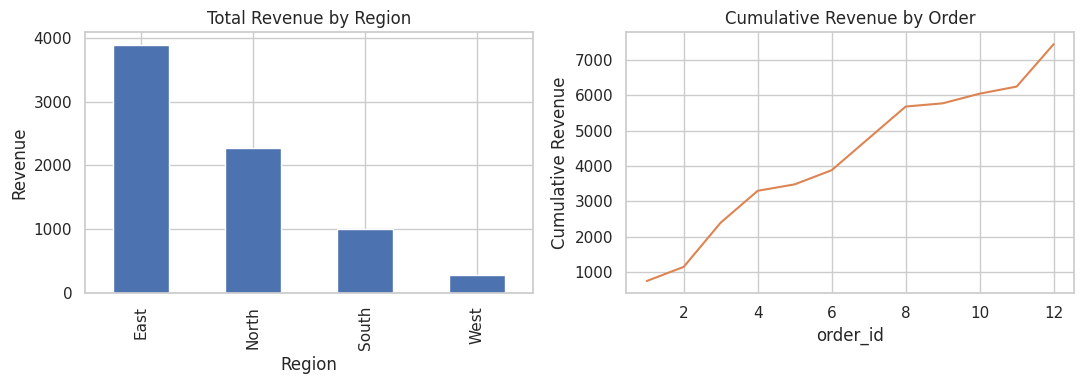

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart: revenue by region
revenue_by_region.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Total Revenue by Region")
axes[0].set_ylabel("Revenue")
axes[0].set_xlabel("Region")

# Line chart: cumulative revenue over order_id (as a proxy for "over time")
merged.sort_values("order_id").set_index("order_id")["revenue"].cumsum().plot(ax=axes[1], color="#DD8452")
axes[1].set_title("Cumulative Revenue by Order")
axes[1].set_ylabel("Cumulative Revenue")

plt.tight_layout()
plt.show()

### 4.2 Seaborn

Seaborn works directly with tidy DataFrames and adds statistical plots (distributions, categorical comparisons, correlation heatmaps) with much less code.

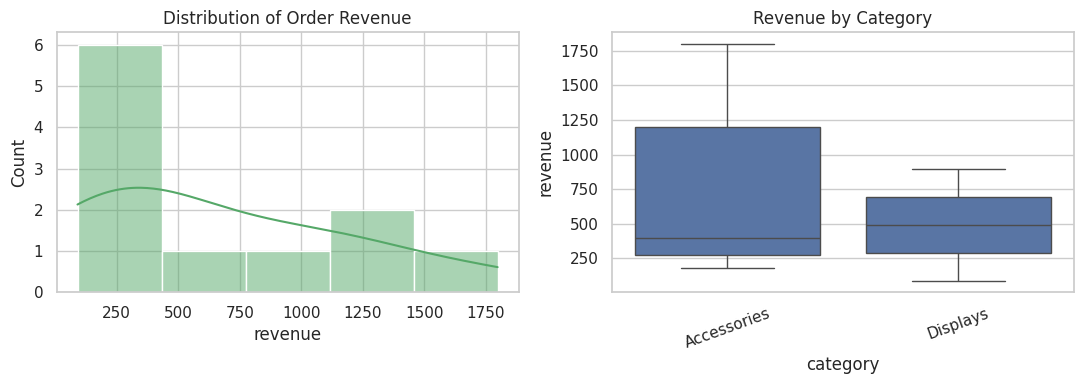

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Distribution of revenue
sns.histplot(merged["revenue"], kde=True, ax=axes[0], color="#55A868")
axes[0].set_title("Distribution of Order Revenue")

# Category vs revenue
sns.boxplot(data=merged, x="category", y="revenue", ax=axes[1])
axes[1].set_title("Revenue by Category")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

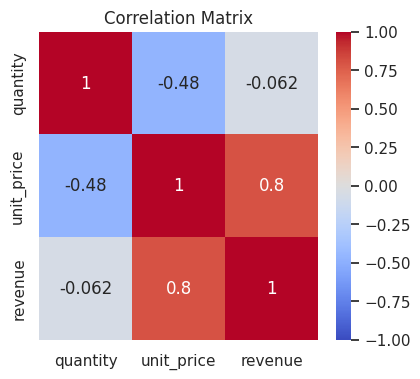

In [ ]:
# Correlation heatmap of the numeric columns
numeric_cols = merged[["quantity", "unit_price", "revenue"]]
corr = numeric_cols.corr()

plt.figure(figsize=(4.5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

**Exercise 4** — Using `merged`, create a Seaborn **bar plot** of average `revenue` per `region`, split further by `category` using the `hue` parameter. Add a title.

In [ ]:
# TODO
# plt.figure(figsize=(8, 4))
# sns.barplot(data=merged, x=..., y=..., hue=...)
# plt.title(...)
# plt.show()

**Solution 4**

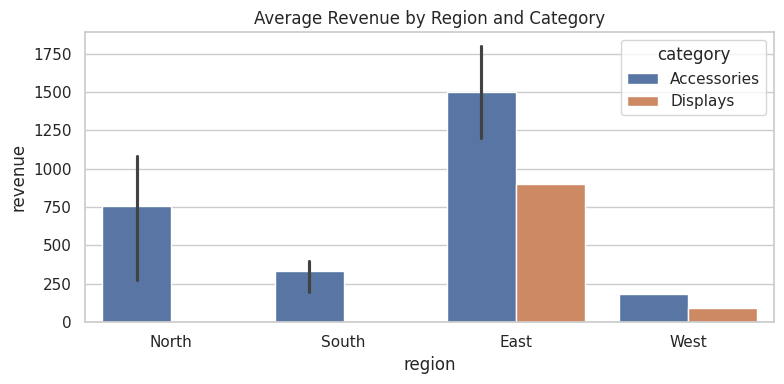

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=merged, x="region", y="revenue", hue="category", estimator="mean")
plt.title("Average Revenue by Region and Category")
plt.tight_layout()
plt.show()

---
## Recap

| Topic | Core tools |
|---|---|
| Python essentials | `def`, `*args`/`**kwargs`, `class`/inheritance, `[... for ... if ...]` |
| NumPy | `np.array`, broadcasting rules, vectorized math (no explicit loops) |
| Pandas | `pd.DataFrame`, `dropna`/`fillna`/`drop_duplicates`, `merge`, `groupby().agg()` |
| Visualization | `matplotlib.pyplot` for control, `seaborn` for statistical plots on DataFrames |

Next steps if you want to go deeper: try swapping in a real dataset (e.g. a CSV you have), and redo sections 3–4 on it.